### 1

#### a)

In [1]:
import pandas as pd
import numpy as np

# Load dataset
dataset = pd.read_csv("income.csv")

# Check variable types
print(dataset.dtypes)

# Check data shape
print("dataset_shape:", dataset.shape)

# Check dataset length
print("dataset_length:", len(dataset))

dataset.head()

income             int64
age                int64
workclass         object
education         object
marital-status    object
occupation        object
relationship      object
race              object
sex               object
hours-per-week     int64
dtype: object
dataset_shape: (26215, 10)
dataset_length: 26215


,income,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week
0,0,39,State-gov,Bachelors,NotMarried,Adm-clerical,Not-in-family,White,Male,40
1,0,50,Self-emp-not-inc,Bachelors,Married,Exec-managerial,Husband,White,Male,13
2,0,38,Private,HS-grad,Separated,Handlers-cleaners,Not-in-family,White,Male,40
3,0,53,Private,11th,Married,Handlers-cleaners,Husband,Black,Male,40
4,0,28,Private,Bachelors,Married,Prof-specialty,Wife,Black,Female,40


In [2]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26215 entries, 0 to 26214
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   income          26215 non-null  int64 
 1   age             26215 non-null  int64 
 2   workclass       24819 non-null  object
 3   education       26215 non-null  object
 4   marital-status  26215 non-null  object
 5   occupation      24814 non-null  object
 6   relationship    26215 non-null  object
 7   race            26215 non-null  object
 8   sex             26215 non-null  object
 9   hours-per-week  26215 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 2.0+ MB


In [3]:
dataset.describe()

,income,age,hours-per-week
count,26215.000000,26215.000000,26215.000000
mean,0.299104,39.045661,40.816632
std,0.457874,13.557816,12.351215
min,0.000000,17.000000,1.000000
25%,0.000000,28.000000,40.000000
50%,0.000000,38.000000,40.000000
75%,1.000000,48.000000,45.000000
max,1.000000,90.000000,99.000000


In [4]:
# Rename columns
dataset = dataset.rename(columns={
    'marital-status': 'marital_status', 
    'hours-per-week': 'hours_per_week'
})

dataset.head()

,income,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week
0,0,39,State-gov,Bachelors,NotMarried,Adm-clerical,Not-in-family,White,Male,40
1,0,50,Self-emp-not-inc,Bachelors,Married,Exec-managerial,Husband,White,Male,13
2,0,38,Private,HS-grad,Separated,Handlers-cleaners,Not-in-family,White,Male,40
3,0,53,Private,11th,Married,Handlers-cleaners,Husband,Black,Male,40
4,0,28,Private,Bachelors,Married,Prof-specialty,Wife,Black,Female,40


In [5]:
# Calculate the correlation matrix
correlation_matrix = dataset.corr()

# Display the correlation matrix
print(correlation_matrix)

                  income       age  hours_per_week
income          1.000000  0.250758        0.246282
age             0.250758  1.000000        0.066981
hours_per_week  0.246282  0.066981        1.000000


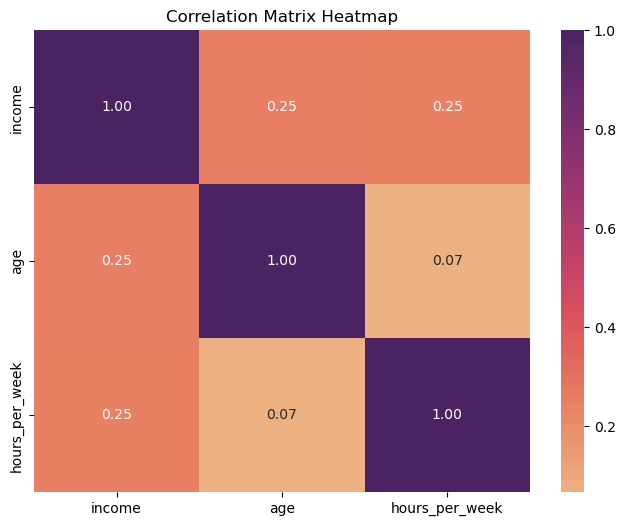

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize correlation matrix
plt.figure(figsize=(8, 6))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='flare', fmt=".2f")

# Show the plot
plt.title('Correlation Matrix Heatmap')
plt.show()

#### b)

In [7]:
# Check missing value
dataset.isnull().sum()

income               0
age                  0
workclass         1396
education            0
marital_status       0
occupation        1401
relationship         0
race                 0
sex                  0
hours_per_week       0
dtype: int64

In [8]:
# Handle missing value
dataset = dataset.dropna()
print("dataset_length:", len(dataset))

dataset_length: 24814


#### c)

In [9]:
# Check duplicated rows
dataset.duplicated().any()

True

In [10]:
# Handle duplicated rows
dataset = dataset.drop_duplicates()
print("dataset_length:", len(dataset))

dataset_length: 21537


#### d)

In [11]:
# Check unique value in dataset
dataset.nunique()

income             2
age               72
workclass          7
education         16
marital_status     4
occupation        14
relationship       6
race               5
sex                2
hours_per_week    94
dtype: int64

In [12]:
# check value count for the categorical variables
print(dataset.workclass.value_counts(),"\n")
print(dataset.education.value_counts(),"\n")
print(dataset.occupation.value_counts(),"\n")
print(dataset.relationship.value_counts(),"\n")
print(dataset.race.value_counts(),"\n")
print(dataset.marital_status.value_counts(),"\n")
print(dataset.sex.value_counts())

Private             15108
Self-emp-not-inc     1999
Local-gov            1656
State-gov            1021
Self-emp-inc          951
Federal-gov           793
Without-pay             9
Name: workclass, dtype: int64 

HS-grad         6442
Some-college    4668
Bachelors       3701
Masters         1324
Assoc-voc       1007
Assoc-acdm       814
11th             718
10th             592
Prof-school      487
7th-8th          427
Doctorate        356
9th              355
12th             296
5th-6th          212
1st-4th          104
Preschool         34
Name: education, dtype: int64 

Prof-specialty       3212
Exec-managerial      3017
Sales                2597
Adm-clerical         2589
Craft-repair         2489
Other-service        2244
Machine-op-inspct    1302
Transport-moving     1136
Handlers-cleaners     862
Farming-fishing       752
Tech-support          692
Protective-serv       522
Priv-house-serv       118
Armed-Forces            5
Name: occupation, dtype: int64 

Husband           892

In [13]:
# Handle categorical variables
# Ordinal variable
dataset['education'] = dataset['education'].replace({'Preschool': 1, '1st-4th': 2, '5th-6th': 3, '7th-8th': 4, '9th': 5, '10th': 6, '11th': 7, '12th': 8, 'HS-grad': 9, 'Some-college': 10, 'Assoc-voc': 11, 'Assoc-acdm': 12, 'Bachelors': 13, 'Masters': 14, 'Prof-school': 15, 'Doctorate': 16})

# Binary variable
dataset['sex'] = dataset['sex'].replace({'Male': 0, 'Female': 1})

# Other categorical variables apply dummy coding
dataset = pd.get_dummies(dataset, columns=['workclass', 'occupation', 'relationship', 'race', 'marital_status'])

dataset.head() 

,income,age,education,sex,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,marital_status_Married,marital_status_NotMarried,marital_status_Separated,marital_status_Widowed
0,0,39,13,0,40,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,50,13,0,13,0,0,0,0,1,...,0,0,0,0,0,1,1,0,0,0
2,0,38,9,0,40,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
3,0,53,7,0,40,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
4,0,28,13,1,40,0,0,1,0,0,...,1,0,0,1,0,0,1,0,0,0


In [14]:
dataset.shape

(21537, 41)

#### e)

In [15]:
# Define the input variables and the target variable
array = dataset.values
X = array[:,1:41]
y = array[:,0]

# Split the training and testing dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print("Training_set:" , len(X_train))
print("Testing_set:" , len(X_test))

Training_set: 19383
Testing_set: 2154


#### f)

In [16]:
# Apply normalization on X (both training and test set)

from sklearn.preprocessing import MinMaxScaler

# fit scaler on training data
norm = MinMaxScaler().fit(X_train)

# transform training data
X_train_norm = norm.transform(X_train)

# transform testing data
X_test_norm = norm.transform(X_test)

### 2

#### a)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# logistic regression model
model = LogisticRegression(solver="liblinear")
model.fit(X_train, y_train)
test_score = model.score(X_test, y_test)
print("Testing Accuracy of Logistic Regression:", test_score)

# SVM for classification
model = SVC()
model.fit(X_train, y_train)
test_score = model.score(X_test, y_test)
print("Testing Accuracy of SVC:", test_score)

Testing Accuracy of Logistic Regression: 0.8059424326833797
Testing Accuracy of SVC: 0.7980501392757661


#### b)

In [18]:
from sklearn.model_selection import KFold

# Set 10-fold cross validation after shuffle the dataset with random state 42
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

from sklearn.model_selection import cross_val_score

model = LogisticRegression(solver="liblinear")
results = cross_val_score(model, X_train_norm, y_train, cv=kfold)
print("Average Accuracy of Logistic Regression:",results.mean())

model = SVC()
results = cross_val_score(model, X_train_norm, y_train, cv=kfold)
print("Average Accuracy of SVM:",results.mean())

Average Accuracy of Logistic Regression: 0.8062218085029945
Average Accuracy of SVM: 0.7985353594221272


#### c)

In [19]:
from sklearn.model_selection import GridSearchCV

# Fine tune parameters for Logistic Regression model
grid_params_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.1, 1, 10, 100],
    'solver': ['saga', 'liblinear']
}

lr = LogisticRegression(max_iter=20000)
gs_lr_result = GridSearchCV(lr, grid_params_lr, cv=kfold).fit(X_train_norm, y_train)
print("Best score of Logistic Regression:", gs_lr_result.best_score_)

Best score of Logistic Regression: 0.8065829257790899


In [21]:
# Fine tune parameters for SVM model
grid_params_svc = {
    'kernel': ['linear', 'poly', 'rbf'],
    'C': [0.1, 1, 10],
    'degree': [3, 8],
    'gamma': ['auto','scale']
}

svc = SVC()
gs_svc_result = GridSearchCV(svc, grid_params_svc, cv=kfold, n_jobs=-1).fit(X_train_norm, y_train)
print("Best score of SVM:", gs_svc_result.best_score_)

Best score of Logistic Regression: 0.8058615161816199


#### d)

In [22]:
# Evaluate optimized Logistic Regression model
test_accuracy = gs_lr_result.best_estimator_.score(X_test_norm, y_test)
print("Logistic Regression Accuracy in testing:", test_accuracy)

# Evaluate optimized SVM model
test_accuracy = gs_svc_result.best_estimator_.score(X_test_norm, y_test)
print("SVM Accuracy in testing:", test_accuracy)

Logistic Regression Accuracy in testing: 0.8064066852367688
SVM Accuracy in testing: 0.8012999071494893


In [25]:
gs_lr_result.best_params_
print("Best result parameters for Logistics regression:", gs_lr_result.best_params_)

Best result parameters for Logistics regression: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}


In [26]:
gs_svc_result.best_params_
print("Best result parameters for SVM:", gs_svc_result.best_params_)

Best result parameters for SVM: {'C': 10, 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf'}


### 3

#### a)

In [30]:
# define input variables
array = dataset.values
X = array[:,1:41] 

# fit scaler on training data
norm = MinMaxScaler().fit(X)
X = norm.transform(X)

# since the income has two classes (0: <=50k, 1: >50k), hence we define the cluster number as 2.
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
print (kmeans)

KMeans(n_clusters=2, random_state=0)


#### b)

In [31]:
# check how many data samples have been assigned to each cluster
import numpy as np

kmeans_labels = kmeans.predict(X)
unique_labels, unique_counts = np.unique(kmeans_labels, return_counts=True)
sample_assigned = dict(zip(unique_labels, unique_counts))
print("Data samples have been assigned to each cluster:", sample_assigned )

Data samples have been assigned to each cluster: {0: 10265, 1: 11272}


#### c)

In [32]:
# Extract a prototype from each cluster 
from sklearn.metrics.pairwise import pairwise_distances_argmin

kmeans_cluster_centers = kmeans.cluster_centers_
closest = pairwise_distances_argmin(kmeans.cluster_centers_, X)

# Show 2 data samples that can represent the 2 clusters
dataset.iloc[closest, :]

,income,age,education,sex,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,marital_status_Married,marital_status_NotMarried,marital_status_Separated,marital_status_Widowed
14215,1,43,11,0,45,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
10908,0,36,10,1,40,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0


#### d)

In [33]:
# Check accuracy of the clustering model
from sklearn.metrics import accuracy_score

y = array[:,-1]

accuracy = accuracy_score(y, kmeans_labels)
print("K means prediction accuracy:", accuracy)

K means prediction accuracy: 0.5066165204067419
